### **Wine Quality Test**
O objetivo deste notebook é estabelecer um modelo de classificação capaz de prever a qualidade de um vinho com base em suas características físico-químicas a partir da base dados disponível.
Para isso, inicialmente, iremos avaliar as variáveis e suas correlações, e então desenvolver e a avaliar os modelos

In [2]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False
})



#### Importando dataset

In [3]:
url = "https://drive.google.com/uc?export=download&id=1jwDD2B0YC4Y2sxCT6hRnAPZ6TByVTssm"

df = pd.read_csv(url)
print('Importado!')


Importado!


### 1. Tratamento da Base
O obejtivo nesta etapa é examinar a estrutura do conjunto de dados afim de compreensão das variáveis presentes. Colunas, os tipos de dados, presença de valores ausentes ou duplicados são analisados ​​para garantir a qualidade e a consistência da informação.

In [4]:
print('Shape:', df.shape)
df.head()

Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [5]:
# Retirada da coluna ID (Não interfere na análise, serve apenas como identificador da amostra)
df = df.drop('Id', axis=1)
print('Retirado coluna Id')
print('Shape:', df.shape)
df.head()

Retirado coluna Id
Shape: (1143, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
# Renomear Colunas para facilitar
df.columns = ['Acidez fixa','Acidez volatil','Acido citrico','Açucar residual','Cloretos','Dioxido de enxofre livre','Dioxido de enxofre total','Densidade','pH','Sulfatos','Teor alcoolico','Qualidade']
df.columns = (df.columns.str.strip().str.replace(' ', '_'))
print('Shape:', df.shape)
df.head()

Shape: (1143, 12)


,Acidez_fixa,Acidez_volatil,Acido_citrico,Açucar_residual,Cloretos,Dioxido_de_enxofre_livre,Dioxido_de_enxofre_total,Densidade,pH,Sulfatos,Teor_alcoolico,Qualidade
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
# Check
print('Valores Vazios:', df.isnull().sum().sum())
print('Duplicados:', df.duplicated().sum())
print('\nResumo de Qualidade:')
print(df['Qualidade'].value_counts().sort_index())
print('\nEstatísticas:')
df.describe().round(2)


Valores Vazios: 0
Duplicados: 125

Resumo de Qualidade:
Qualidade
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Estatísticas:


,Acidez_fixa,Acidez_volatil,Acido_citrico,Açucar_residual,Cloretos,Dioxido_de_enxofre_livre,Dioxido_de_enxofre_total,Densidade,pH,Sulfatos,Teor_alcoolico,Qualidade
count,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00
mean,8.31,0.53,0.27,2.53,0.09,15.62,45.91,1.00,3.31,0.66,10.44,5.66
std,1.75,0.18,0.20,1.36,0.05,10.25,32.78,0.00,0.16,0.17,1.08,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.20,0.55,9.50,5.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,37.00,1.00,3.31,0.62,10.20,6.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,61.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00


In [8]:
# Eliminar linhas duplicadas (amostras iguais)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape:', df.shape)

Shape: (1018, 12)


In [9]:
# Check 2
print('Valores Vazios:', df.isnull().sum().sum())
print('Duplicados:', df.duplicated().sum())
print('\nResumo de Qualidade:')
print(df['Qualidade'].value_counts().sort_index())
print('\nEstatísticas:')
df.describe().round(2)


Valores Vazios: 0
Duplicados: 0

Resumo de Qualidade:
Qualidade
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64

Estatísticas:


,Acidez_fixa,Acidez_volatil,Acido_citrico,Açucar_residual,Cloretos,Dioxido_de_enxofre_livre,Dioxido_de_enxofre_total,Densidade,pH,Sulfatos,Teor_alcoolico,Qualidade
count,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00,1018.00
mean,8.29,0.53,0.27,2.52,0.09,15.65,46.33,1.00,3.31,0.66,10.45,5.64
std,1.74,0.18,0.20,1.31,0.05,10.18,33.12,0.00,0.16,0.17,1.10,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.72,11.20,6.00
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00


#### Análise da Variável-alvo
Estabelecendo as notas de qualidade como variável de referência para a classificação dos vinhos, vamos observar seu comportamento dentro do contexto

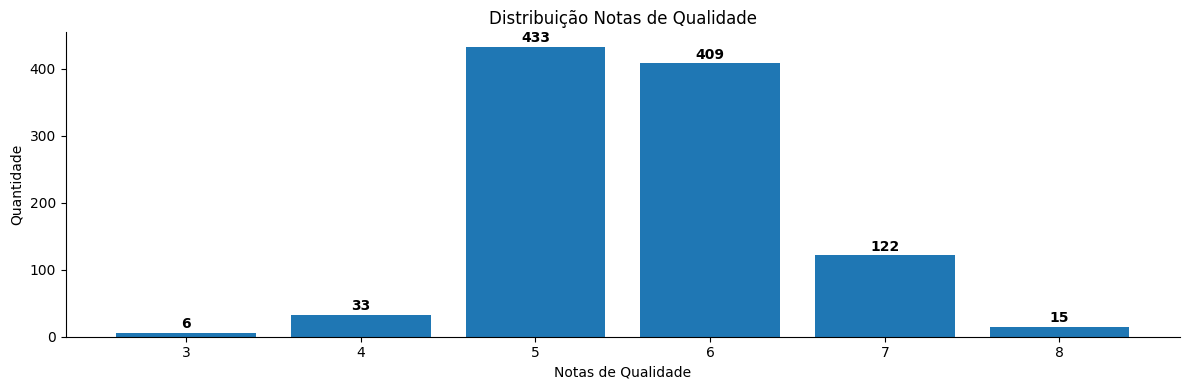

Mediana da Qualidade: 6.0


,Acidez_fixa,Acidez_volatil,Acido_citrico,Açucar_residual,Cloretos,Dioxido_de_enxofre_livre,Dioxido_de_enxofre_total,Densidade,pH,Sulfatos,Teor_alcoolico
Qualidade,,,,,,,,,,,
3,7.45,0.8175,0.05,2.1,0.0800,5.5,15.0,0.997565,3.355,0.56,9.825
4,7.60,0.6750,0.07,2.1,0.0780,12.0,32.0,0.996640,3.380,0.56,10.000
5,7.80,0.5900,0.23,2.2,0.0820,15.0,48.0,0.996900,3.300,0.58,9.700
6,7.90,0.5000,0.26,2.2,0.0780,14.0,35.0,0.996520,3.320,0.64,10.500
7,8.55,0.3600,0.40,2.3,0.0705,12.0,27.5,0.995495,3.275,0.74,11.600
8,8.60,0.3600,0.45,2.0,0.0720,7.0,19.0,0.995160,3.230,0.74,11.800


In [10]:
# Distribuição da notas de qualidade
fig, ax = plt.subplots(figsize=(12, 4))
qtde = df['Qualidade'].value_counts().sort_index()

barras = ax.bar(qtde.index, qtde.values)
ax.set_title('Distribuição Notas de Qualidade')
ax.set_xlabel('Notas de Qualidade')
ax.set_ylabel('Quantidade')
ax.bar_label(barras, padding= 1, fontweight = "bold")
plt.tight_layout()
plt.show()

print('Mediana da Qualidade:', df['Qualidade'].median())
df.groupby("Qualidade").median()

#### Transformar variável de qualidade em classificação binária
Conforme distribuição e como o intuito é classificar apenas em "Bom" e "Não Bom", adotaremos como "Bom" maior ou igual a 7 uma vez que fica acima da média e mediana com 7 e 8 representando um desempenho claramente acima do padrão. Além de que uma quantidade próxima entre as notas 5 e 6 pode dificultar os modelos a distinguir amostras similares a estes perfis.

In [11]:
df['Classificação'] = (df['Qualidade'] >= 7).astype(int) # Se 1 Qualidade Alta, se 0 Qualidade Regular/Baixa.
df = df.drop(columns=['Qualidade'])
contagem = df.Classificação.sum()
print(f'Qualidade Regular/Baixa: {df.Classificação.value_counts().sum() - contagem}')
print(f'Qualidade Alta: {contagem}')


Qualidade Regular/Baixa: 881
Qualidade Alta: 137


### 2. Análise Exploratória


Utilizando o boxplot e histograma para avaliar as características de distribuiçãos das variáveis.

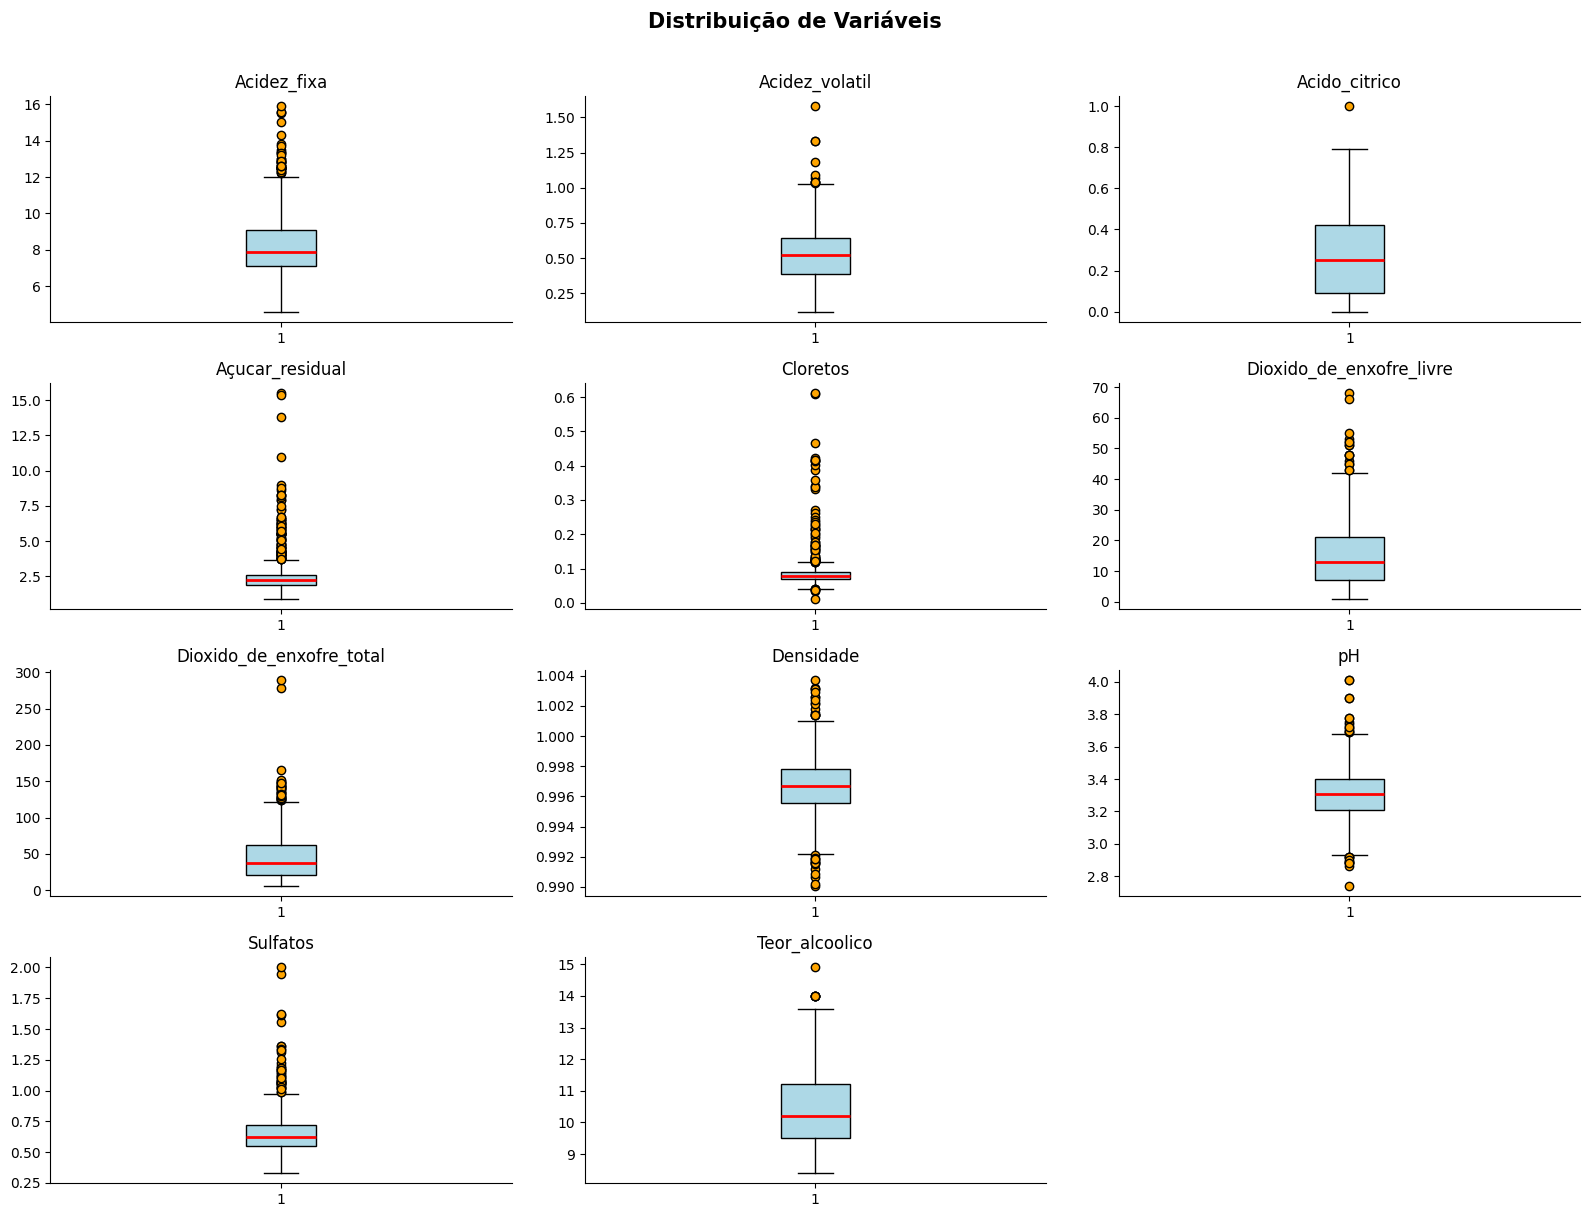

In [12]:
cols = [c for c in df.columns if c not in ['Classificação']]

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes_flat = axes.ravel()

for i, col in enumerate(cols):
    ax = axes_flat[i]
    ax.boxplot(df[col].dropna(),
               patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=6))
    ax.set_title(col, fontsize=12)

for j in range(len(cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Distribuição de Variáveis', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

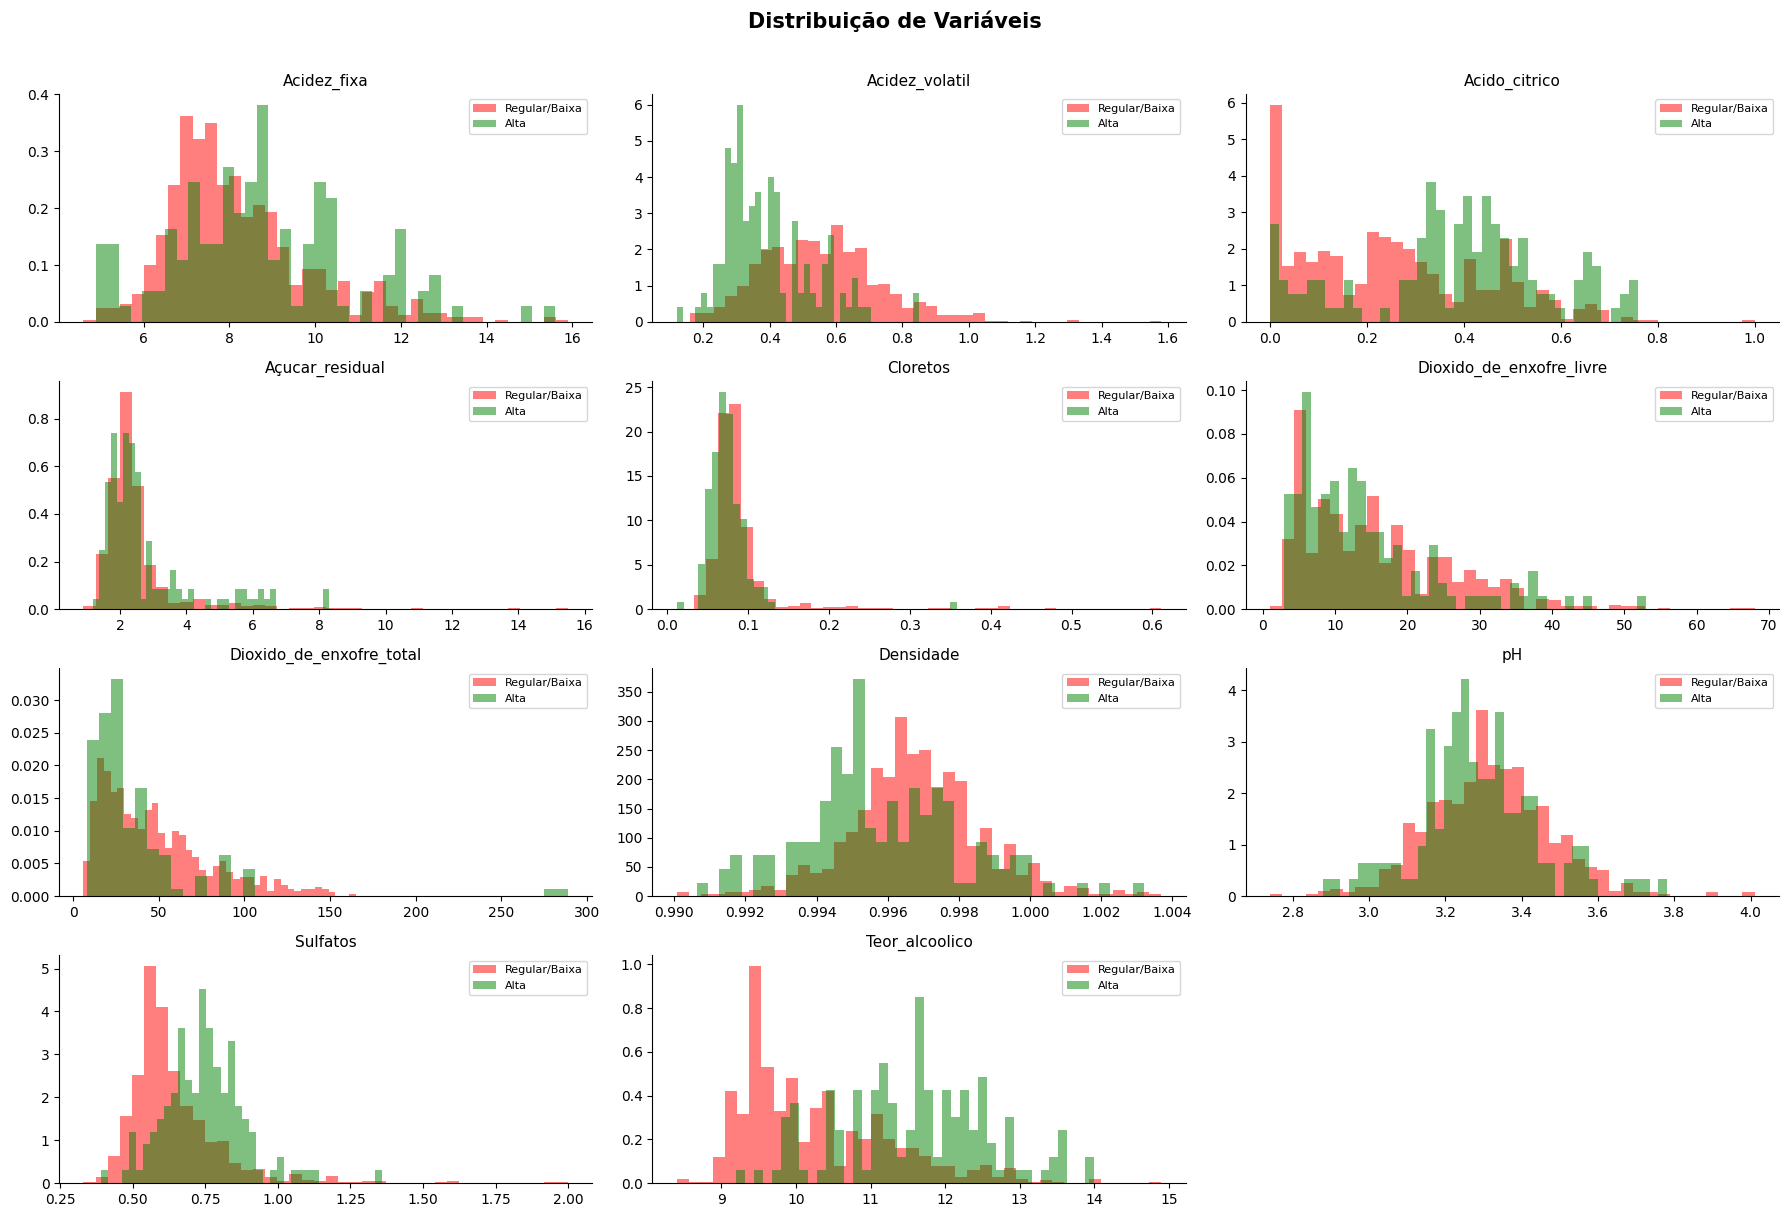

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
axes_flat = axes.ravel()

for i, col in enumerate(cols):
    ax = axes_flat[i]
    for label, color, name in [(0, "red", 'Regular/Baixa'),
                                (1, "green", 'Alta')]:
        ref = df[df['Classificação'] == label][col]
        ax.hist(ref,bins=40, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

for j in range(len(cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Distribuição de Variáveis', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

É possivel observar uma maior frequência de vinhos de alta qualidade com maior teor alcoolico e menor acidez volátil, assim como bons níveis de sulfatos e ácido cítrico, e relativa baixa densidade

Abaixo o mapa de calor de correlação ajuda a identificar quais variáveis ​​tendem a variar em conjunto e quais apresentam tendências opostas.

Nesta etapa, podemos verificar:
- Variáveis ​​fortemente correlacionadas entre si;
- Variáveis ​​que apresentam correlação significativa com a Qualidade (Classificação);
- Possível redundância entre variáveis ​​que podem conter informações semelhantes.

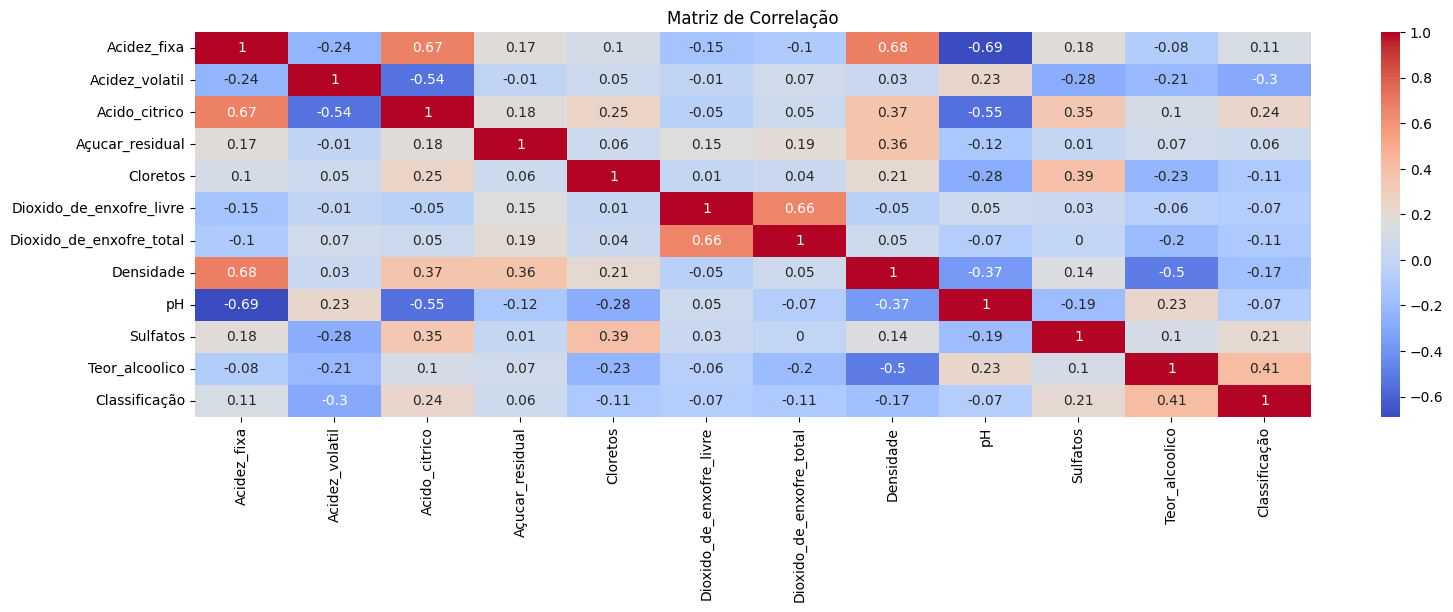

In [14]:
plt.figure(figsize=(18,5))
sns.heatmap(df.corr().round(2),annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

A matriz de correlação revela as seguintes relações principais:

- Acidez Fixa e pH (-0.69): Apresentam uma forte correlação negativa. Isso é quimicamente esperado, pois o pH é uma medida da concentração de íons de hidrogênio, quanto maior a quantidade de ácidos fixos (como o tartárico), menor será o valor do pH;

- Acidez Fixa e Densidade (0.68): Existe uma forte correlação positiva. Ácidos orgânicos são mais densos que a água e o álcool, portanto, vinhos com maior acidez fixa tendem a ter uma densidade total mais elevada;

- Acidez Fixa e Ácido Cítrico (0.67): Estão positivamente correlacionados, pois o ácido cítrico é um dos componentes que integram a acidez fixa total do vinho;

- Densidade e Teor Alcoólico (-0.5): Demonstram uma correlação negativa moderada. Como o álcool (etanol) possui densidade inferior à da água, um aumento no teor alcoólico reduz a densidade global do vinho.

Baseado na correlação dos dados acima, as variáveis que têm maior influência na qualidade do vinho são o **Teor Alcoólico** e a **Acidez Volátil** seguido do **Ácido Cítrico** e **Sulfatos**. Onde:

- Teor Alcoólico (0.41) é a variável com a maior correlação positiva indicando que vinhos com graduações alcoólicas mais elevadas tendem a receber notas de classificação superiores. O álcool contribui para o corpo e a percepção de doçura, equilibrando os ácidos do vinho;

- Acidez Volátil (-0.3): Possui uma correlação negativa significativa. Como a acidez volátil está ligada à presença de ácido acético (o principal componente do vinagre), níveis elevados são indesejáveis e resultam em uma queda na percepção de qualidade;

- Ácido Cítrico (0.24): Apresenta uma correlação positiva, sugerindo que a presença deste ácido, que adiciona "frescor" ao vinho, está associada a uma melhor classificação;

- Sulphatos (0.21): Também mostram uma correlação positiva com a qualidade, eles atuam como agentes antimicrobianos e antioxidantes ajudando a preservar as características desejadas do vinho.

### 3. Desenvolvendo Modelos
Aqui o objetivo é treinar 2 modelos de classificação e comparar o desempenho entre eles. Para isso utilizaremos o Random Forest e o KNN que são dois modelos supervisionados porém com princípios diferentes, um baseado em árvore de decisão e outro em distância para os vizinhos próximos.

Como temos uma distribuição desbalanceada da variável-alvo, utilizaremos também as técnicas de class_weight.

In [15]:
# Importar bibliotecas para os modelos
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, make_scorer

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold



In [16]:
# Separar variáveis preditoras (X) e alvo (y)
X = df.drop(['Classificação'], axis=1)
y = df['Classificação']

# Separar em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Treino:', X_train.shape, ' Teste:', X_test.shape)

Treino: (814, 11)  Teste: (204, 11)


#### Random Forest
Este é um modelo baseado em árvore de decisão. Não necessita de normalização/padronização das variáveis e permite analisar a importância de cada uma delas.

In [17]:
# Usando o GridSearchCV para encontrar melhores hiperparâmetros
param_rf = {'n_estimators': [100, 150, 200], 'max_depth': [3, 5, 7]}

rf = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')

grid_rf = GridSearchCV(rf,
                    param_grid=param_rf,
                    scoring='precision',
                    cv=5, n_jobs=-1, verbose=3)

grid_rf.fit(X_train, y_train)
print('Random Forest', grid_rf.best_params_)
print(round((grid_rf.best_score_),4))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Random Forest {'max_depth': 7, 'n_estimators': 200}
0.5261


In [18]:
# Testando o modelo
y_pred = grid_rf.predict(X_test)

print('Acurácia:', round(accuracy_score(y_test, y_pred),4))
print('Relatório de Classificação:\n', classification_report(y_test, y_pred))

Acurácia: 0.9118
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       177
           1       0.70      0.59      0.64        27

    accuracy                           0.91       204
   macro avg       0.82      0.78      0.79       204
weighted avg       0.91      0.91      0.91       204



In [19]:
kfold  = KFold(n_splits=5, shuffle=True) # shuffle=True, Shuffle (embaralhar) os dados.
result = cross_val_score(rf, X, y, cv = kfold)

print("K-Fold (R^2) Scores: {0}".format(result))
print("Mean R^2 for Cross-Validation K-Fold: {0}".format(result.mean()))

K-Fold (R^2) Scores: [0.86764706 0.90686275 0.85294118 0.9408867  0.87684729]
Mean R^2 for Cross-Validation K-Fold: 0.8890369941079881


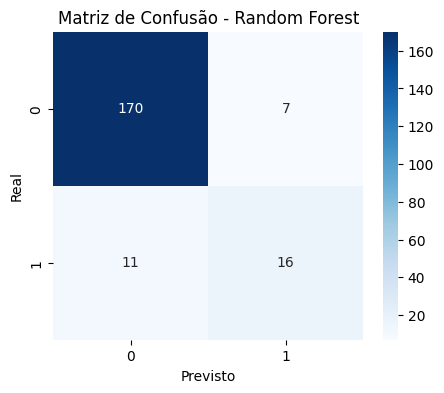

In [20]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

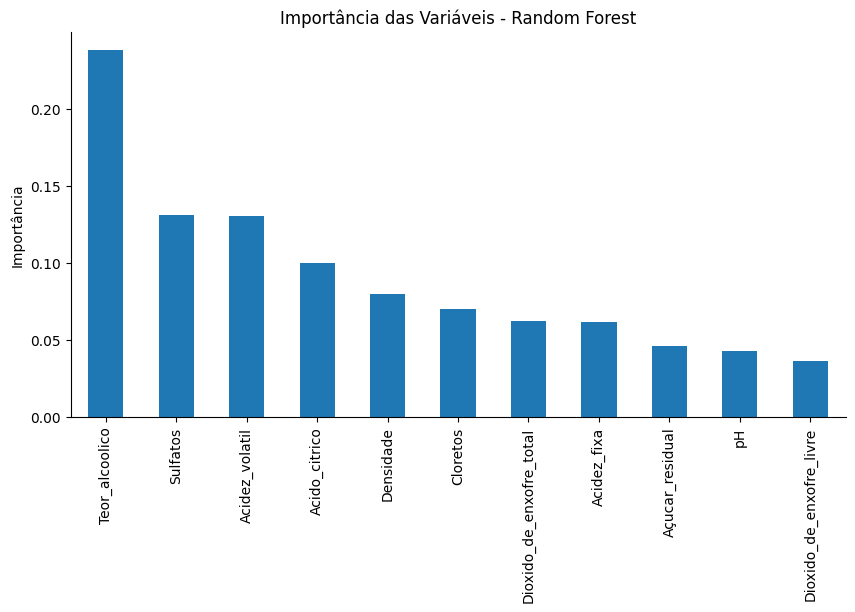

In [21]:
# Importância das variáveis no Random Forest
importancias = pd.Series(grid_rf.best_estimator_.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
importancias.plot(kind='bar')
plt.title('Importância das Variáveis - Random Forest')
plt.ylabel('Importância')
plt.show()

##### Sobre as importâncias das variáveis no Random Forest:

- O Teor Alcoólico é a variável mais importante para o modelo determinar se um vinho é premium, com mais de 20% de peso.
- Sulfatos e Acidez Volátil formam o segundo escalão mais relevante, empatados com cerca de 13% cada.
- Ácido Cítrico fecha o bloco das quatro principais forças condutoras da qualidade física do produto (10%).

#### KNN (K-Nearest Neighbors)
Este é um modelo baseado em distância, classificando a partir de vizinhos mais próximos. Neste caso, é importante padronizar a escala para evitar que o algoritmo assuma que algumas variáveis sejam mais importantes que outras apenas por estarem em um escala maior.

In [22]:
# Aplicando padronização
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

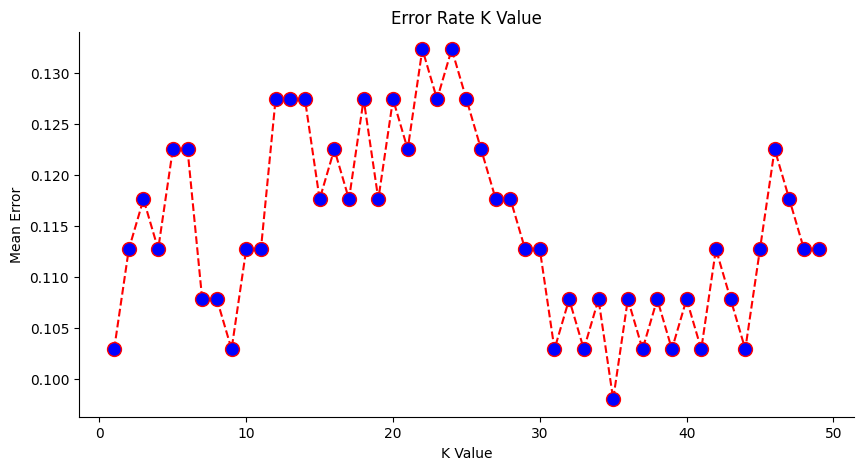

In [23]:
# Encontrando o melhor K
error = [] #armazenar os erros

for k in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 50), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

plt.show()

In [24]:
# Usando o GridSearchCV para encontrar melhores hiperparâmetros
param_knn = {'weights': ['uniform', 'distance'], #Função de peso usada na previsão
            'metric':['cosine', 'euclidean', 'manhattan'] #métrica para cálculo da distância
             }

knn = KNeighborsClassifier(n_neighbors= 35) # K=35 é ponto onde o erro médio é mínimo

grid_knn = GridSearchCV(knn,
                    param_grid=param_knn,
                    scoring='precision',
                    cv=5, n_jobs=-1, verbose=3)

grid_knn.fit(X_train_scaled, y_train)
print('Random Forest', grid_knn.best_params_)
print(round((grid_knn.best_score_),4))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Random Forest {'metric': 'manhattan', 'weights': 'uniform'}
0.7167


In [25]:
# Testando o modelo
y_pred_knn = grid_knn.predict(X_test_scaled)

print('Acurácia:', round(accuracy_score(y_test, y_pred_knn),4))
print('Relatório de Classificação:\n', classification_report(y_test, y_pred_knn))

Acurácia: 0.8922
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       177
           1       0.73      0.30      0.42        27

    accuracy                           0.89       204
   macro avg       0.81      0.64      0.68       204
weighted avg       0.88      0.89      0.87       204



In [26]:
kfold  = KFold(n_splits=5, shuffle=True) # shuffle=True, Shuffle (embaralhar) os dados.
result = cross_val_score(knn, X, y, cv = kfold)

print("K-Fold (R^2) Scores: {0}".format(result))
print("Mean R^2 for Cross-Validation K-Fold: {0}".format(result.mean()))

K-Fold (R^2) Scores: [0.86764706 0.86764706 0.87254902 0.82758621 0.89162562]
Mean R^2 for Cross-Validation K-Fold: 0.8654109919830001


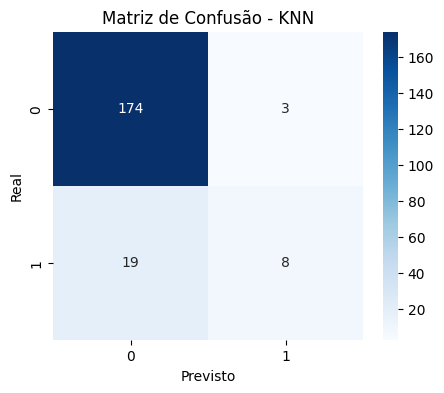

In [27]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

#### Comparativo entre modelos

In [28]:
resultado = {
    'Modelo': ['KNN', 'Random Forest'],
    'Accuracy': [round((accuracy_score(y_test, y_pred_knn)),4), round((accuracy_score(y_test, y_pred)),4)],
    'F1': [round((f1_score(y_test, y_pred_knn)),4),round((f1_score(y_test, y_pred)),4)]
}

pd.DataFrame(resultado)

,Modelo,Accuracy,F1
0,KNN,0.8922,0.4211
1,Random Forest,0.9118,0.6400


### 4. Interpretação dos Resultados

Como temos uma base desbalanceada entre vinhos de Alta Qualidade e vinhos de baixa/média, vimos comportamento bem distinto entre identificação de cada classe. Ambos modelos têm bom desempenho na classe majoritária (0 - baixa/média qualidade), agora comparando o desempenho na classe minoritária (1 - Alta Qualidade), em resumo:

- Acurácia Global: Random Forest (0.9118) vs. KNN (0.8922)
- Recall (Sensibilidade): Random Forest (0.59) vs. KNN (0.30)
- Precision (Precisão): Random Forest (0.70) vs. KNN (0.73)
- F1-Score (Equilíbrio): Random Forest (0.64) vs. KNN (0.42)

O Random Forest mostrou-se mais favorável e equilibrado.
1. Captura o dobro de vinhos bons: O KNN identificou apenas 30% dos vinhos premium disponíveis no teste (deixando passar 70% como vinhos de baixa/média qualidade). O Random Forest encontrou 59%, sendo muito mais lucrativo comercialmente.

2. Superioridade estrutural: O KNN calcula distâncias no espaço de atributos. O Random Forest lida melhor com a assimetria da variável-alvo por meio de árvores independentes e pesos de classe ajustados.

A precisão ligeiramente maior do KNN (73% contra 70% do Random Forest) não compensa a perda ao ignorar a maioria dos vinhos excelentes.